<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/dp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1- Introduction + Set-up


In [1]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [2]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [3]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 95.5MB/s]



In [4]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# 2- EDA

In [5]:

# check the folder strucutre
import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")


TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


**Note**
Dataset is already imnalanced, we have to shuffle and balance it...

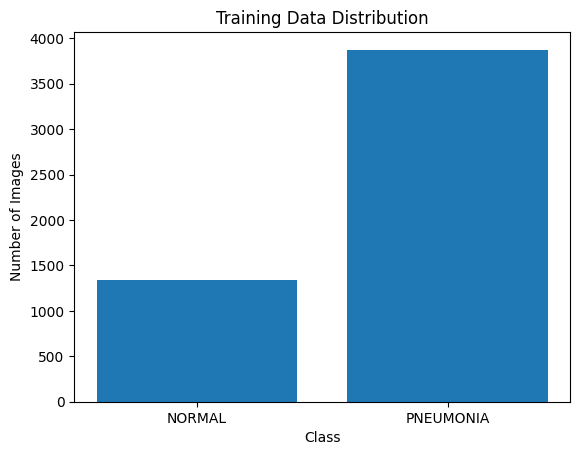

In [ ]:
# visulize that
import matplotlib.pyplot as plt

train_counts = {'NORMAL': 1341, 'PNEUMONIA': 3875}

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## 2-2 Show sample images

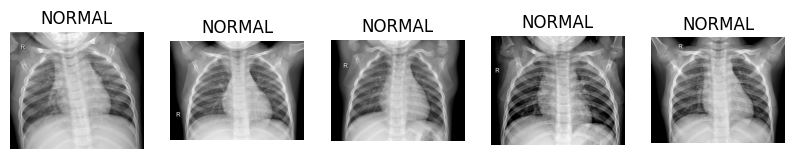

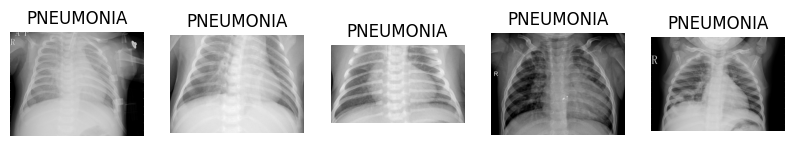

In [6]:
# show some sample images

import matplotlib.pyplot as plt
import cv2
import os

def show_samples(base_path, split, label):
    path = os.path.join(base_path, split, label)
    images = os.listdir(path)[:5]  # show 5 images

    plt.figure(figsize=(10, 3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')

    plt.show()

show_samples(base_path, 'train', 'NORMAL')
show_samples(base_path, 'train', 'PNEUMONIA')

**Note**  
Images are clear, mostly, and some of them do not have the same size

##  2-3 Check image sizes (CRUCIAL before model)

In [7]:
sizes = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:100]:  # sample 100
        img = cv2.imread(os.path.join(path, img_name))
        sizes.append(img.shape)

print(set(sizes))

{(784, 1200, 3), (664, 1016, 3), (1348, 1608, 3), (1113, 1430, 3), (1684, 1742, 3), (517, 895, 3), (570, 886, 3), (1012, 1496, 3), (680, 936, 3), (752, 1088, 3), (544, 840, 3), (728, 1080, 3), (1550, 1816, 3), (752, 1048, 3), (864, 1392, 3), (594, 765, 3), (816, 1048, 3), (1503, 1800, 3), (1109, 1522, 3), (584, 896, 3), (552, 1008, 3), (951, 1246, 3), (1422, 1792, 3), (1040, 1380, 3), (1069, 1214, 3), (576, 976, 3), (1267, 1732, 3), (1206, 1414, 3), (1700, 2110, 3), (1302, 1512, 3), (1086, 1164, 3), (970, 1410, 3), (1252, 1666, 3), (1560, 1904, 3), (1148, 1310, 3), (1476, 1956, 3), (1739, 1898, 3), (1121, 1418, 3), (619, 966, 3), (1175, 1620, 3), (1217, 1650, 3), (994, 1214, 3), (755, 1056, 3), (1048, 1472, 3), (1399, 1736, 3), (1192, 1328, 3), (1815, 1857, 3), (736, 1128, 3), (885, 1268, 3), (1476, 1812, 3), (378, 650, 3), (2169, 1962, 3), (1121, 1384, 3), (597, 808, 3), (896, 1272, 3), (1096, 1664, 3), (1148, 1364, 3), (680, 1000, 3), (1129, 1678, 3), (1615, 1754, 3), (824, 1160, 3),

**Note** as we can clrearly see now, they absolutely DO NOT have a unified size, so we have to consifer this

## 2-4 Pixel distribution (advanced but powerful)

**WARNING** System will crash before running this:

In [ ]:
import numpy as np
import os

pixels = []

for label in ['NORMAL', 'PNEUMONIA']:
    path = os.path.join(base_path, 'train', label)

    for img_name in os.listdir(path)[:50]:
        img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
        pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

**Note** Skipping Pixel Distrubution due to not enough RAM

# DAY 4
Proper Split,
Preprocessing,
Normalization

The issues that we have we have right now are:

TRAIN: ok but imbalanced

VAL: too small ❌

TEST: keep it untouched ✅

## 1- Train / Validation Split

## Handle Imbalance

✔ EDA
✔ Split (you just did this)
✔ Class weights (you just did this)
⬜ Preprocessing (next)
⬜ Model

**Note** Stratified Split garuntees that the dataset is trustworthy

Splitting → makes evaluation fair

Class weights → makes learning fair

✔ EDA

✔ Proper split (huge step)

✔ Understand imbalance

⬜ Preprocessing (next)

⬜ Training

Check old data

In [8]:
import os
from collections import Counter

base_path = "chest_xray"

def count_split(split):
    counts = {}
    for label in os.listdir(os.path.join(base_path, split)):
        path = os.path.join(base_path, split, label)
        counts[label] = len(os.listdir(path))
    return counts

print("ORIGINAL TRAIN:", count_split("train"))
print("ORIGINAL VAL:", count_split("val"))
print("ORIGINAL TEST:", count_split("test"))

ORIGINAL TRAIN: {'NORMAL': 1341, 'PNEUMONIA': 3875}
ORIGINAL VAL: {'NORMAL': 8, 'PNEUMONIA': 8}
ORIGINAL TEST: {'NORMAL': 234, 'PNEUMONIA': 390}


Check new data (memory)

## Prprocessing

In [9]:
# ================================
# 🧠 IMPORTS
# ================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
# ================================
# ⚙️ PREPROCESSING PIPELINE
# ================================

# Training generator (includes normalization + augmentation later if needed)
train_datagen = ImageDataGenerator(
    rescale=1./255   # 🔥 normalize pixels (0–255 → 0–1)
)

# Validation generator (ONLY normalization)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [11]:
# ================================
# 📊 LOAD DATA (WITH SPLIT BUILT-IN)
# ================================

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",   # original train folder
    target_size=(64, 64),  # 🔥 resize all images
    batch_size=32,
    class_mode='binary',
    subset=None   # we will not use built-in split here
)

Found 5216 images belonging to 2 classes.


In [12]:
# ================================
# 📊 TRAIN + VAL SPLIT INSIDE GENERATOR
# ================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 🔥 80/20 split
)

train_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'   # 🔥 training part
)

val_generator = train_datagen.flow_from_directory(
    "chest_xray/train",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # 🔥 validation part
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


In [13]:
# NEW

# Now we do all of these new steps instead
# ADD THIS as a new cell right after ↑
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_array = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_array),
    y=train_labels_array
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)
print("Class mapping:", train_generator.class_indices)

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


**Note**
what happend?
✔ Split data (again, but properly)
✔ Resize images (224x224)
✔ Normalize pixels (0–1)
✔ Load in batches (no RAM crash)
✔ Shuffle automatically

**Note** We want to resize to (112, 112) to make the images smaller

In [14]:
# ================================
# 🧪 TEST GENERATOR
# ================================

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "chest_xray/test",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # ❗ important for evaluation
)

Found 624 images belonging to 2 classes.


In [15]:
# Get a batch (images + labels)
images, labels = next(test_generator)

In [16]:
print(images.shape)

(32, 64, 64, 3)


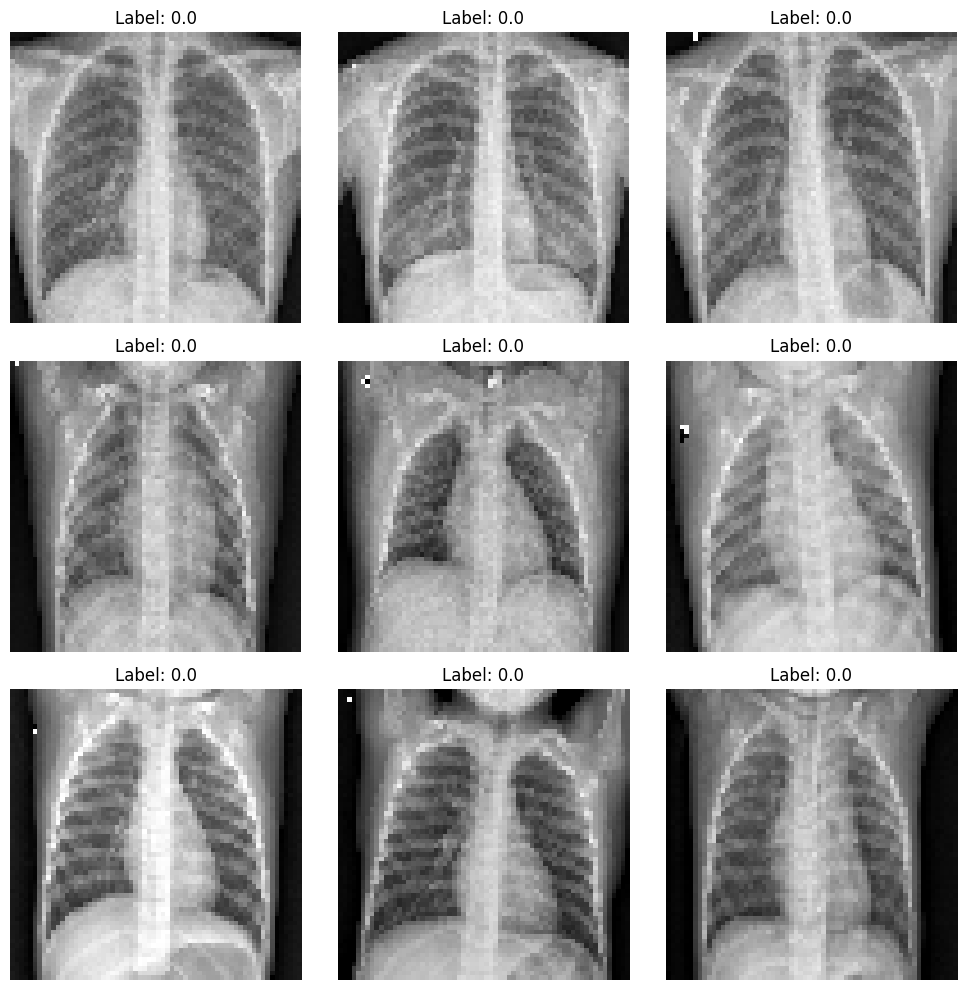

In [17]:
import matplotlib.pyplot as plt

# Get a batch
images, labels = next(test_generator)

# Show first 9 images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Fitting and Training

## 1- first model ANN

In [18]:
# using keras
import tensorflow as tf
from tensorflow import keras

In [36]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[64, 64, 3]),

    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dropout(0.2),    # randomly dropout 20%

    keras.layers.Dense(1, activation="sigmoid") # best for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 300)            │     3,686,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,716,901 (14.18 MB)

 Trainable params: 3,716,901 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

**NOTES**
- lots of parameters, we expect overfitting of course.
- we might need to do dropping and l1/l2

In [37]:
# let us try to train the model without any reglization
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])


**NOTES**
- binary_crossentropy as the loss function, the name is self explanotary
- adam is really good for binary classification
- We might wanna adjust the learning rate


In [38]:
# fitting the model
history = model.fit(train_generator, validation_data=val_generator, epochs=30, class_weight=class_weights_dict)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 431ms/step - accuracy: 0.7508 - loss: 0.6903 - val_accuracy: 0.9089 - val_loss: 0.2375
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - accuracy: 0.8874 - loss: 0.2755 - val_accuracy: 0.8974 - val_loss: 0.2404
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 403ms/step - accuracy: 0.9073 - loss: 0.2311 - val_accuracy: 0.9386 - val_loss: 0.1723
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 404ms/step - accuracy: 0.8938 - loss: 0.2658 - val_accuracy: 0.8802 - val_loss: 0.3019
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 404ms/step - accuracy: 0.9156 - loss: 0.2180 - val_accuracy: 0.9396 - val_loss: 0.1567
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - accuracy: 0.9111 - loss: 0.2295 - val_accuracy: 0.9367 - val_loss: 0.1552
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 53s 407ms/step - accuracy: 0.9013 - loss: 0.2205 - val_accuracy: 0.8715 - val_loss: 0.3077
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 410ms/step - accuracy: 0.9154 - loss: 0

**Note** clear overfitting, time for the graphs

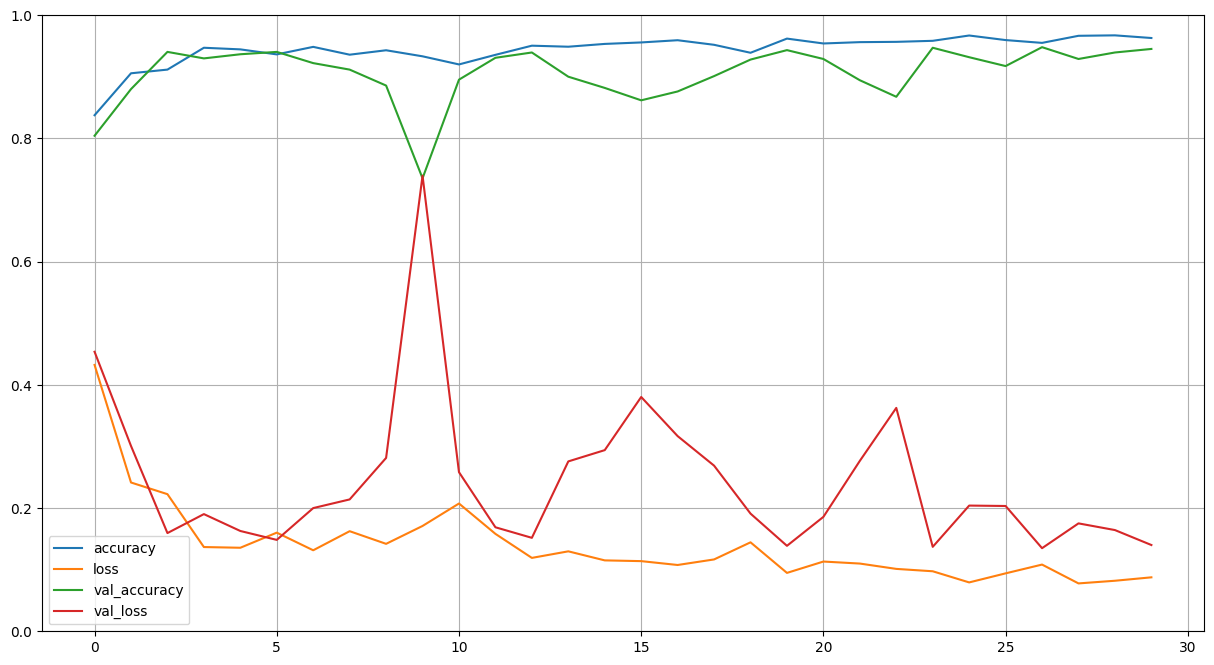

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

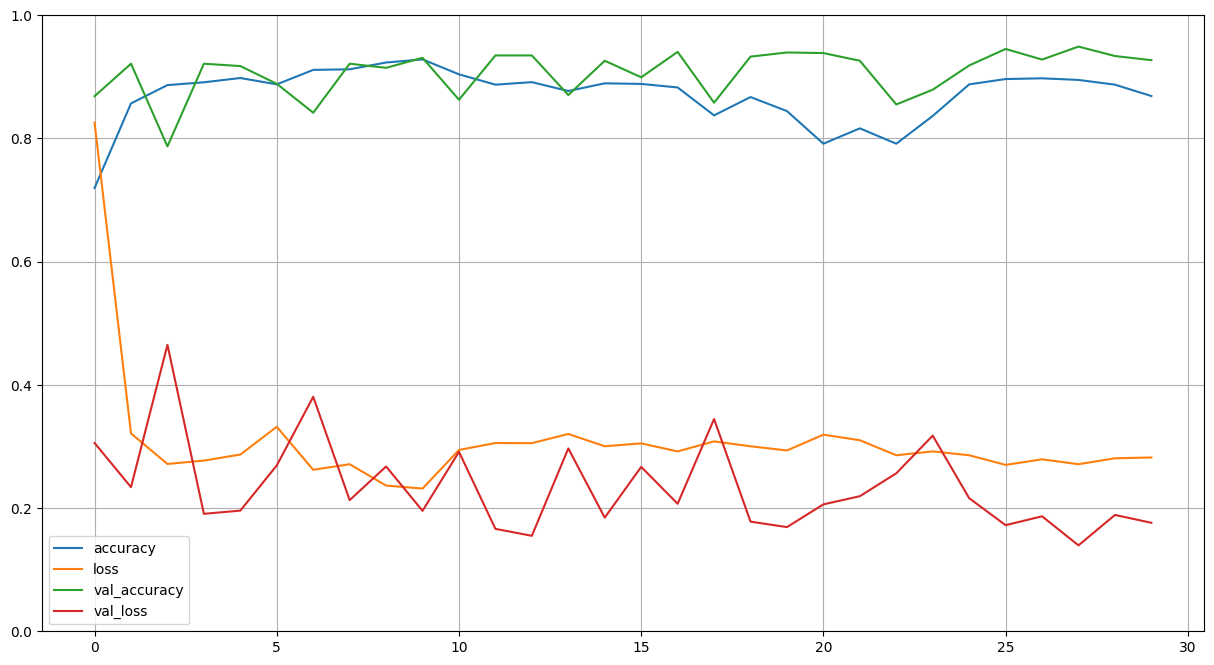

In [ ]:
# after dropout
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Note**
- Signs of underfitting this time around, let us bring the drop out rate down a notch

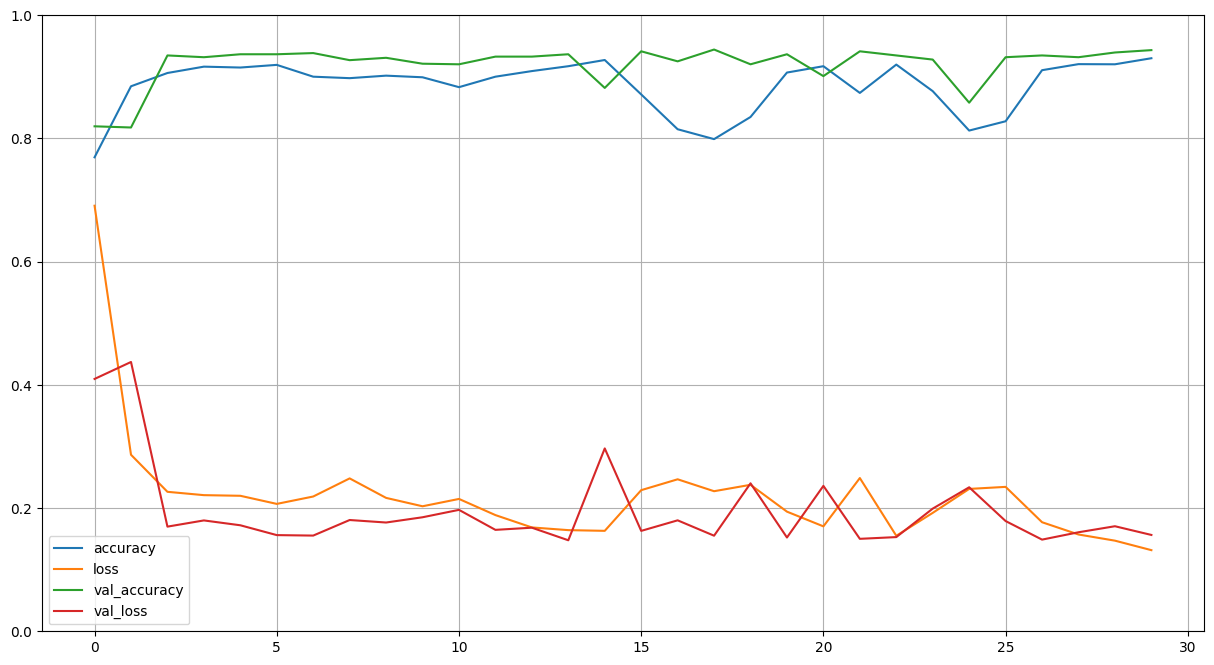

In [ ]:
# after 20% drop out (not underfitting really)
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

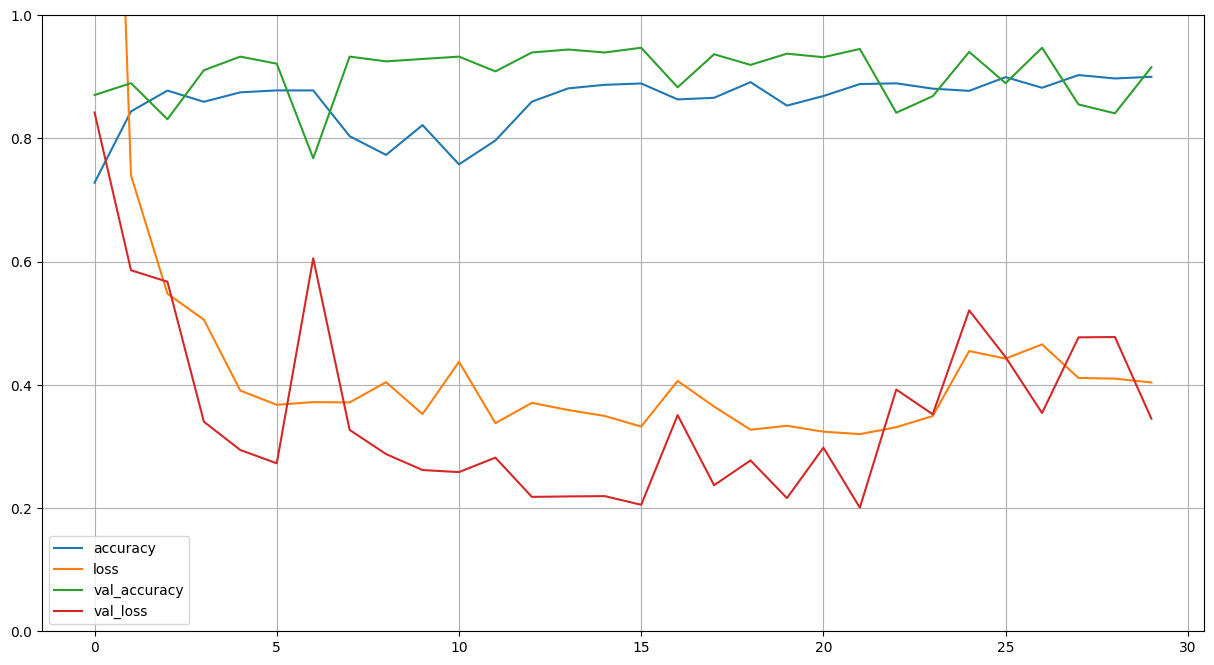

In [35]:
# graph after l2 reg
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

**Notes**
to be fair, we did not choose the alpha value, but since our 20% frop out model was good enough, based on the graph, we should keep that

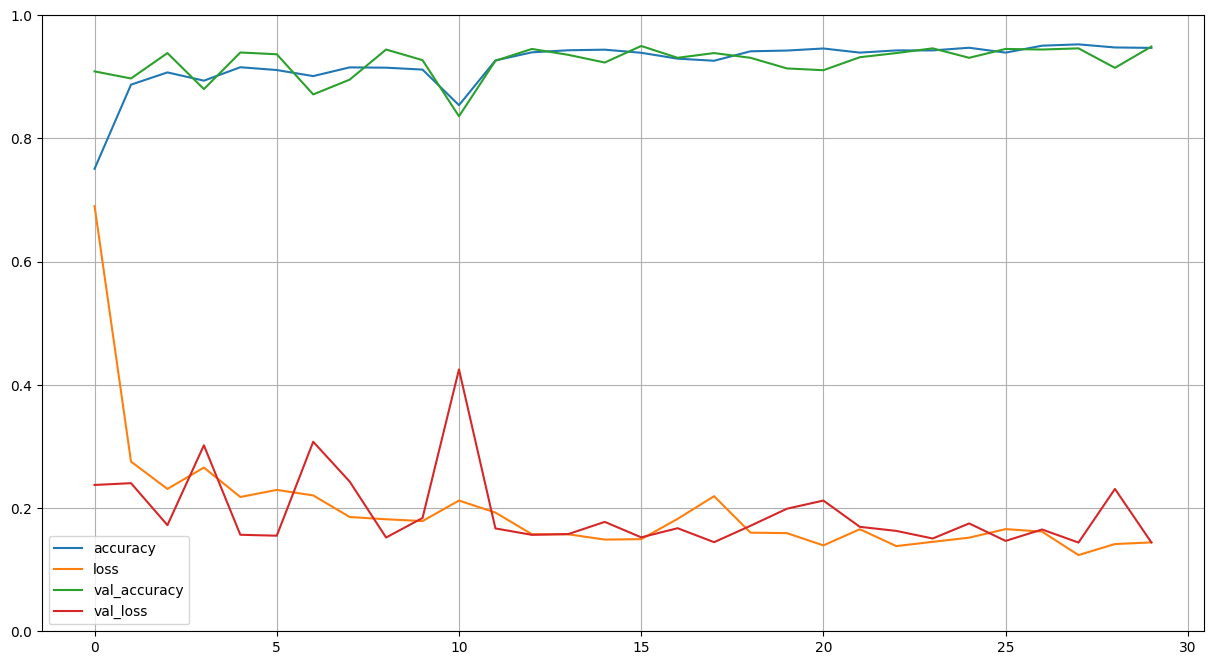

In [39]:
# checking if the 20% dropout model is still solid
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(15, 8))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step


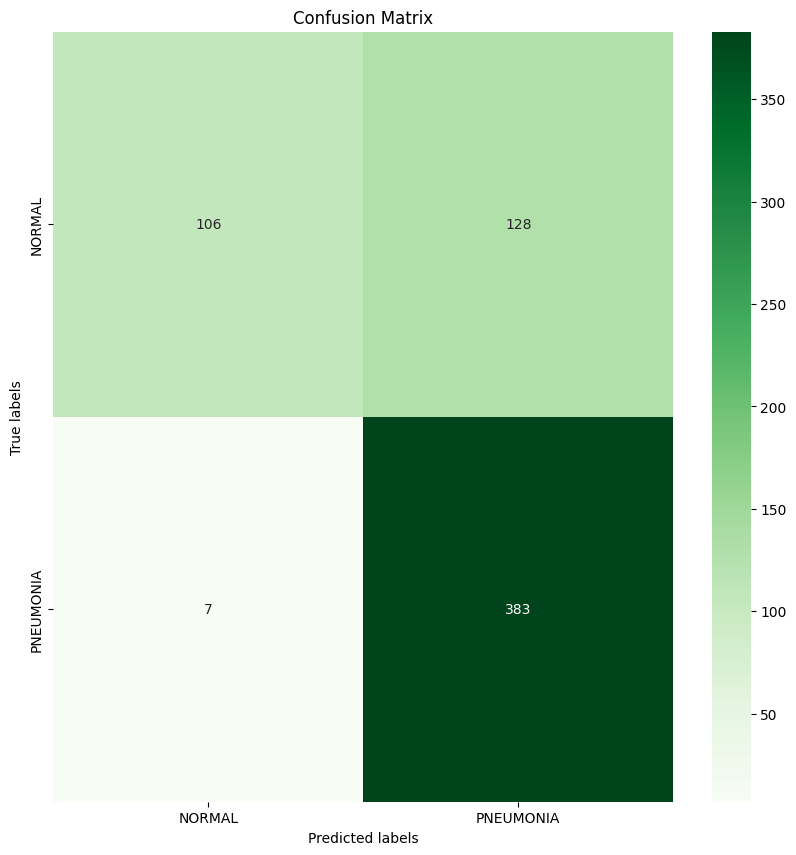

In [ ]:
# confusion matrix
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1 - get predictions from the model
predictions = model.predict(test_generator)

# 2 - convert probabilities to class labels (0 or 1)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# 3 - get the true labels from the generator
true_classes = test_generator.classes

# 4 - class names in the right order
class_names = ['NORMAL', 'PNEUMONIA']  # 0=NORMAL, 1=PNEUMONIA

# 5 - compute the matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 6 - plot it
plt.figure(figsize=(6, 4))
fig = sb.heatmap(cm, annot=True, fmt='g', cmap='Greens')

fig.set_xlabel('Predicted labels')
fig.set_ylabel('True labels')
fig.set_title('Confusion Matrix')
fig.xaxis.set_ticklabels(class_names)
fig.yaxis.set_ticklabels(class_names)
fig.figure.set_size_inches(10, 10)

plt.show()

**NOTES**
In medics, We do not wanna to tell a sick person that he's fine